<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/Clusterizacao_aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

In [2]:
iris = load_iris()

In [4]:
df = pd.DataFrame(iris.data, columns= iris.feature_names)

In [5]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

In [7]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


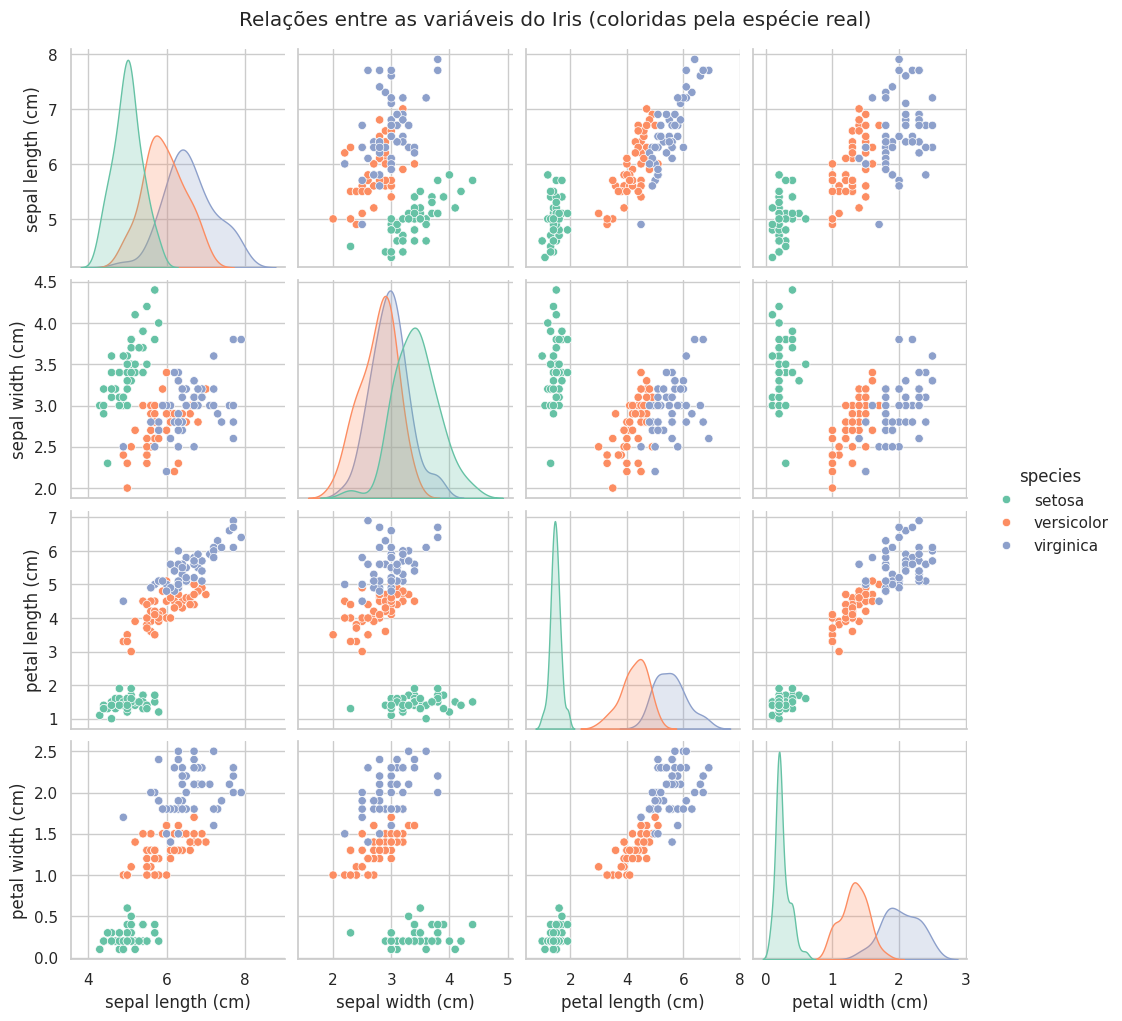

In [9]:
sns.pairplot(df, hue="species", diag_kind="kde", palette="Set2")
plt.suptitle("Relações entre as variáveis do Iris (coloridas pela espécie real)", y=1.02)
plt.show()


# Clusterização

## 1. Divisão dos dados em X (porque não usamos a target em um modelo não supervisionado, portanto não temos o y)

In [10]:
X  = df[iris.feature_names].values

## 2. Padronização dos dados, porque obrigatoriamente pricisamos deixar todos os valores na mesma escala em um modelo de aprendizado não supervisinado

In [14]:
scaler = StandardScaler()

In [16]:
X_scaled = scaler.fit_transform(X)

In [18]:
X_scaled_df = pd.DataFrame(X_scaled, columns = iris.feature_names)

In [19]:
X_scaled_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


## 3. Rodar um Agrupamento Hierarquico

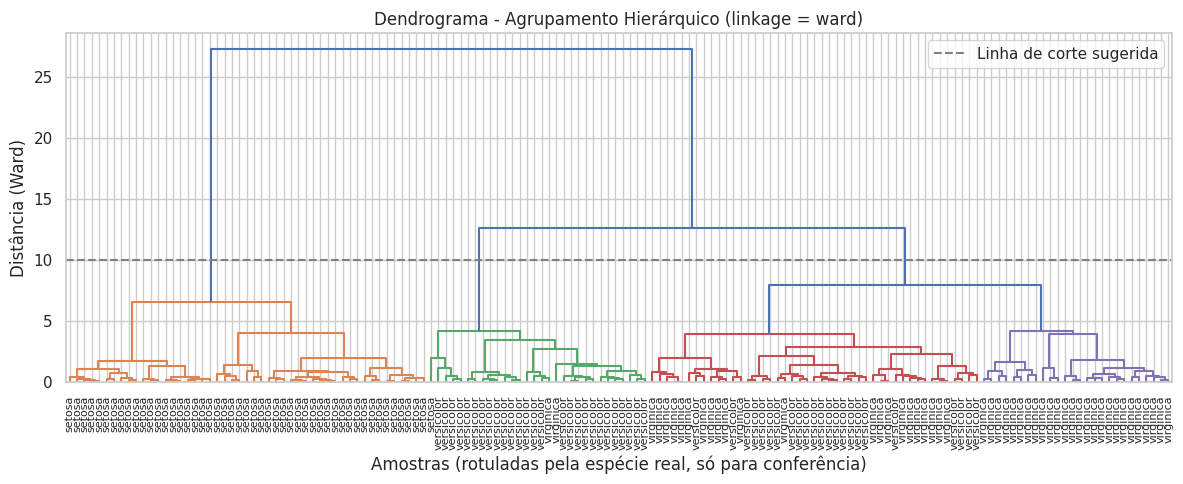

In [23]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(
    Z,
    labels=df["species"].values,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=7,  # linha de corte usada para colorir os ramos
)
plt.title("Dendrograma - Agrupamento Hierárquico (linkage = ward)")
plt.xlabel("Amostras (rotuladas pela espécie real, só para conferência)")
plt.ylabel("Distância (Ward)")
plt.axhline(y=10, color="gray", linestyle="--", label="Linha de corte sugerida")
plt.legend()
plt.tight_layout()
plt.show()

y = 7, quantos clusters?

4

y= 3, quantos clusters?

11

Qual é o ideal?

y = 10

3 clusters


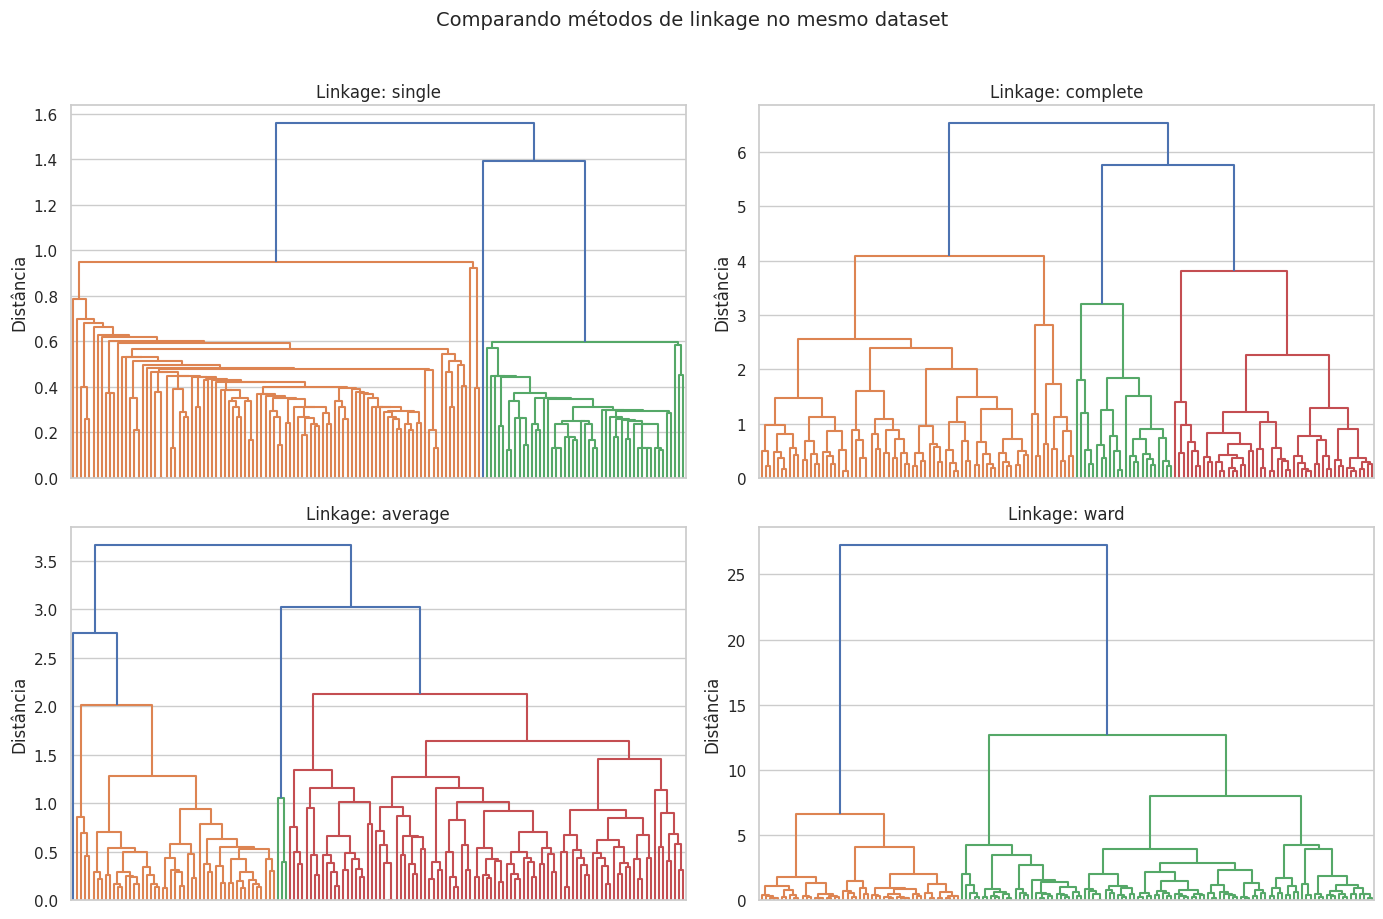

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
methods = ["single", "complete", "average", "ward"]

for ax, method in zip(axes.flat, methods):
    Z_method = linkage(X_scaled, method=method)
    dendrogram(Z_method, ax=ax, no_labels=True)
    ax.set_title(f"Linkage: {method}")
    ax.set_ylabel("Distância")

plt.suptitle("Comparando métodos de linkage no mesmo dataset", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [26]:
hier_labels = fcluster(Z, t=3, criterion="maxclust")
df["cluster_hierarquico"] = hier_labels

# Comparando os clusters encontrados com as espécies reais
comparacao_hier = pd.crosstab(df["species"], df["cluster_hierarquico"],
                               rownames=["Espécie real"], colnames=["Cluster (hierárquico)"])
comparacao_hier

Cluster (hierárquico),1,2,3
Espécie real,,,
setosa,49,1,0
versicolor,0,27,23
virginica,0,2,48


# Agrupamento Particionado = K-Means

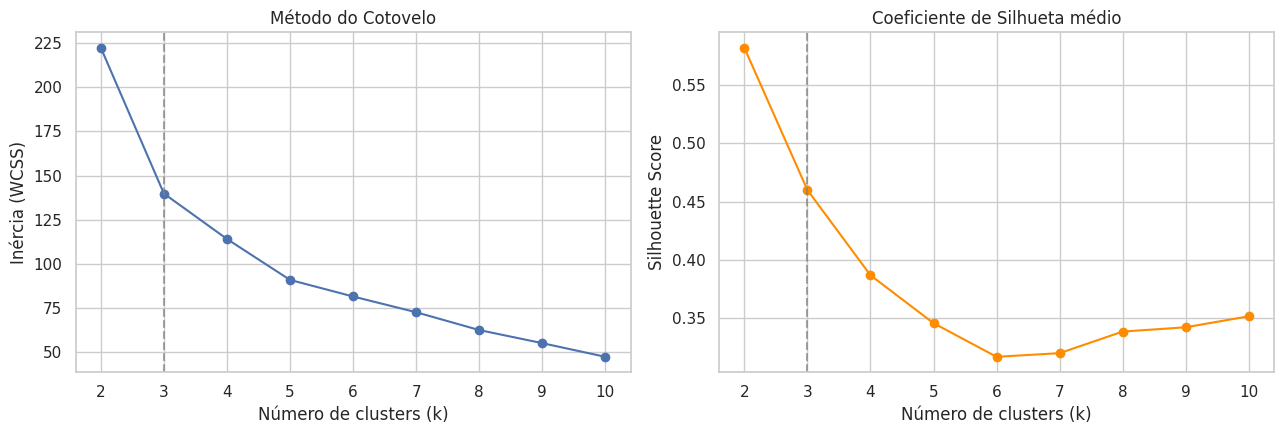

In [27]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km_labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km_labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Método do Cotovelo")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inércia (WCSS)")
axes[0].axvline(x=3, color="gray", linestyle="--", alpha=0.7)

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Coeficiente de Silhueta médio")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].axvline(x=3, color="gray", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()



In [30]:
# Vamos seguir com k=3, apoiados no conhecimento de domínio (3 espécies)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df["cluster_kmeans"] = kmeans_labels

comparacao_kmeans = pd.crosstab(df["species"], df["cluster_kmeans"],
                                 rownames=["Espécie real"], colnames=["Cluster (K-Means)"])
comparacao_kmeans

Cluster (K-Means),0,1,2
Espécie real,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


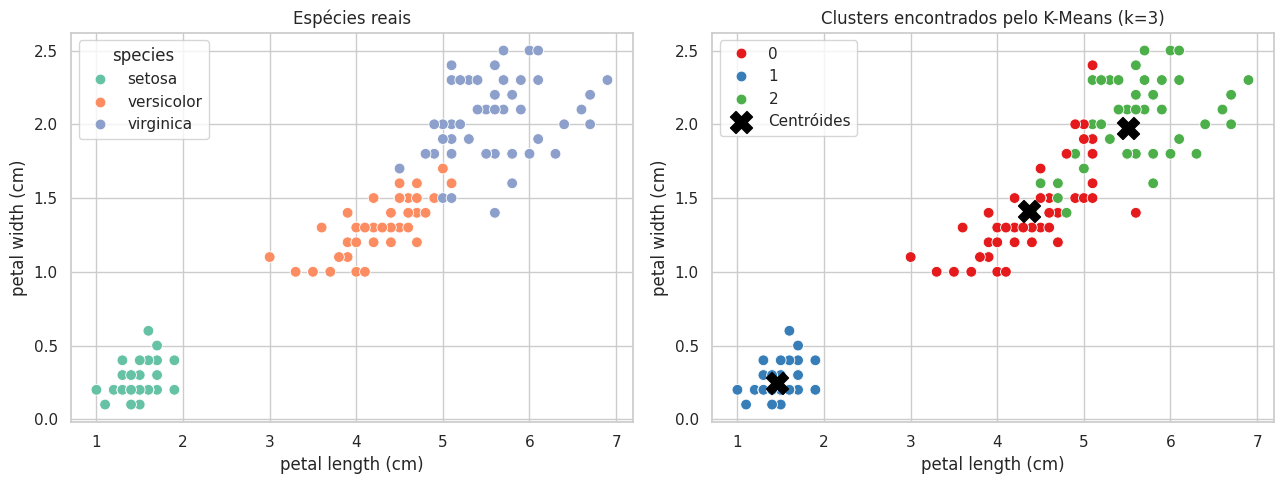

In [31]:
# Visualizando os clusters do K-Means no espaço das pétalas (as 2 variáveis mais discriminativas)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=df, x="petal length (cm)", y="petal width (cm)",
    hue="species", palette="Set2", ax=axes[0], s=60
)
axes[0].set_title("Espécies reais")

sns.scatterplot(
    data=df, x="petal length (cm)", y="petal width (cm)",
    hue="cluster_kmeans", palette="Set1", ax=axes[1], s=60
)
# Centróides no espaço original (aproximado via inverse_transform)
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
axes[1].scatter(centroids_original[:, 2], centroids_original[:, 3],
                 marker="X", s=250, c="black", label="Centróides")
axes[1].set_title("Clusters encontrados pelo K-Means (k=3)")
axes[1].legend()

plt.tight_layout()
plt.show()

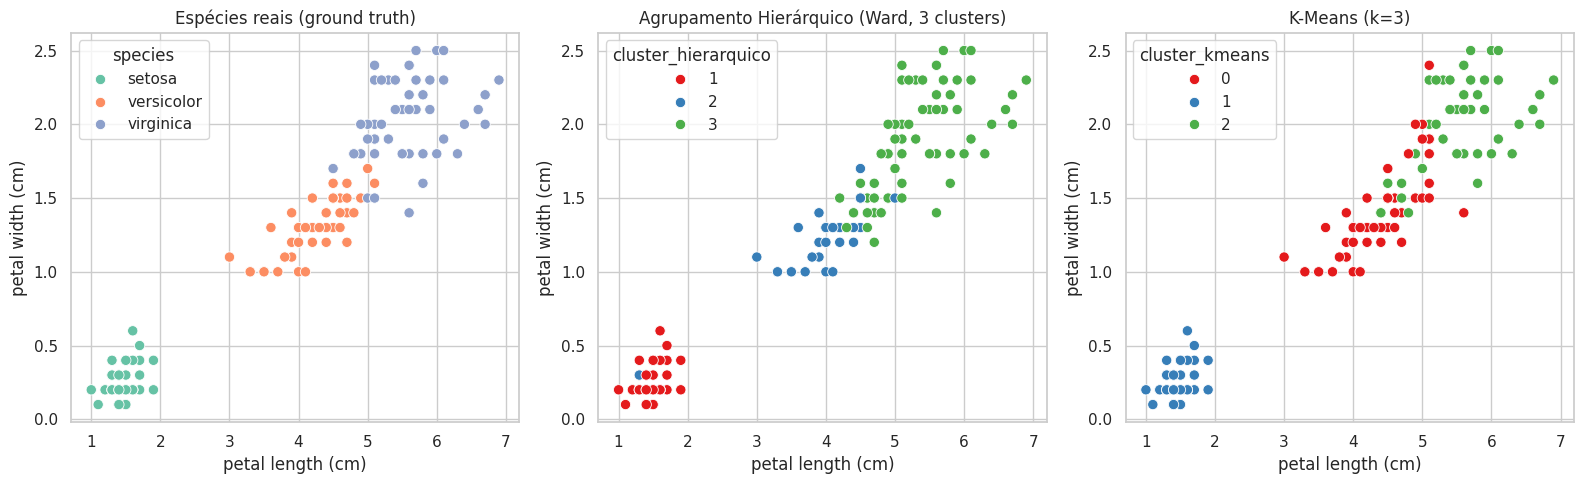

Taxa de concordância aproximada entre os dois métodos de clustering:
83.3% das amostras caíram em clusters 'equivalentes' nos dois métodos


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)",
                 hue="species", palette="Set2", ax=axes[0], s=55, legend=True)
axes[0].set_title("Espécies reais (ground truth)")

sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)",
                 hue="cluster_hierarquico", palette="Set1", ax=axes[1], s=55, legend=True)
axes[1].set_title("Agrupamento Hierárquico (Ward, 3 clusters)")

sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)",
                 hue="cluster_kmeans", palette="Set1", ax=axes[2], s=55, legend=True)
axes[2].set_title("K-Means (k=3)")

plt.tight_layout()
plt.show()

print("Taxa de concordância aproximada entre os dois métodos de clustering:")
concordancia = (pd.crosstab(df["cluster_hierarquico"], df["cluster_kmeans"])
                 .values.max(axis=1).sum() / len(df))
print(f"{concordancia:.1%} das amostras caíram em clusters 'equivalentes' nos dois métodos")